# Term-induced distribution plots

This notebook demonstrates every term-induced distribution plotting function in `liesel_ptm`. It uses real `liesel_gam` terms with simulated coefficient draws, so no MCMC fit is required.

The plots isolate the selected term. Intercepts and lower-order tensor marginals are included only when their concrete term objects are supplied explicitly.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import liesel.model as lsl
import liesel_gam as gam
import numpy as np
import pandas as pd

import liesel_ptm as ptm


def linear_basis(x):
    x = jnp.squeeze(x, axis=-1)
    return jnp.column_stack((jnp.ones_like(x), x))


def simulated_samples(term, key, scale=0.12, center=None, chains=1, draws=1):
    shape = (chains, draws) + term.coef.value.shape
    center = jnp.zeros_like(term.coef.value) if center is None else center
    return {term.coef.name: center + scale * jax.random.normal(key, shape)}


dist = ptm.onion_dist(a=-4.0, b=4.0, nparam=4)
dimension_scale = jnp.eye(4)
keys = jax.random.split(jax.random.key(42), 10)

## Intercept

The intercept plot shows one induced distribution. Quantile ribbons are on by default; HDI lines and sampled trajectories are opt-in.

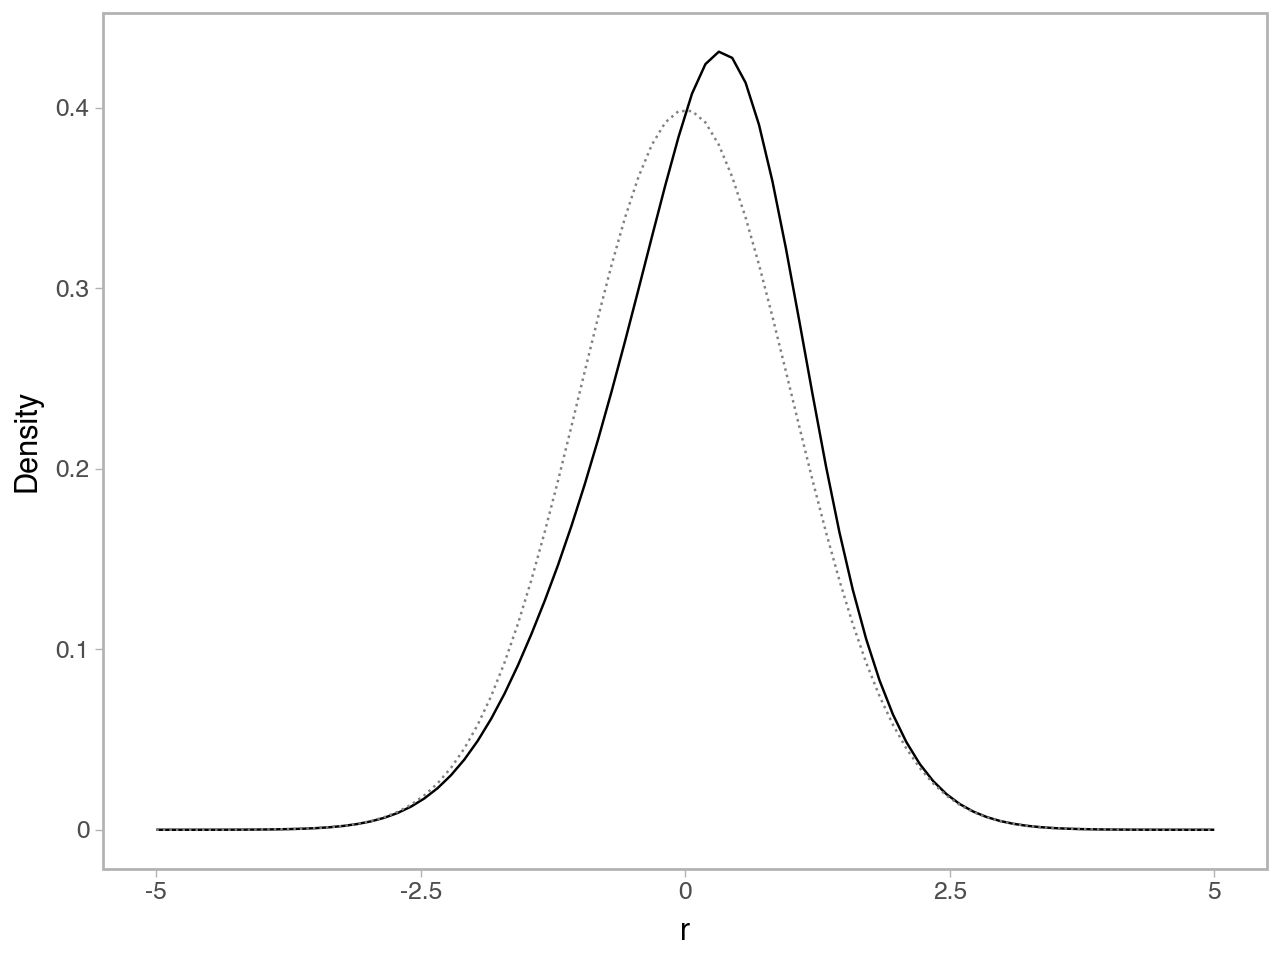

In [2]:
intercept_builder = gam.MVTermBuilder.from_df(
    pd.DataFrame({"x": [0.0, 1.0]}), dimension_scale
)
intercept = intercept_builder.intercept(scale=0.1)
intercept_model = lsl.Model([intercept])
intercept_samples = simulated_samples(intercept, keys[0], scale=0.2)

ptm.plot_intercept_dist(
    dist,
    intercept,
    intercept_samples,
    rgrid=80,
    # hdi_prob=0.8,
    # show_n_samples=5,
    seed=4,
)

## One-dimensional smooth

Density curves are placed on covariate baselines and colored by the covariate. Low values use the lowest baseline and high values the highest. The y-axis is hidden by default; pass `show_y_axis=True` to restore the covariate labels. Reference distributions are shown as gray dotted lines.

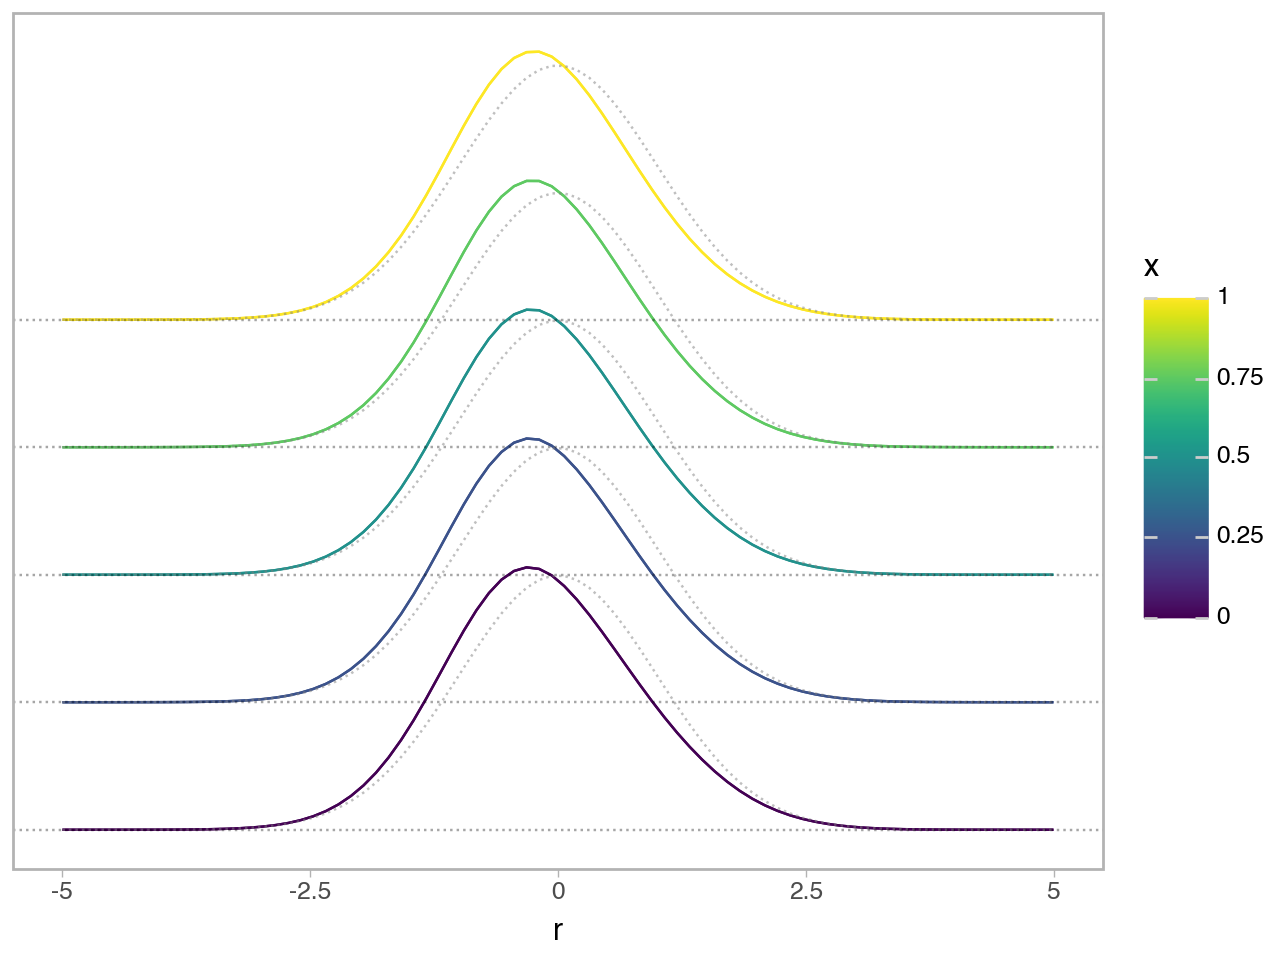

In [3]:
smooth_data = pd.DataFrame({"x": np.linspace(0.0, 1.0, 20)})
smooth_builder = gam.MVTermBuilder.from_df(smooth_data, dimension_scale)
smooth = smooth_builder.f(
    "x",
    basis_fn=linear_basis,
    penalty=jnp.eye(2),
    scale=1.0,
    dimension_scale=1.0,
    use_callback=False,
)
smooth_model = lsl.Model([smooth])
smooth_samples = simulated_samples(smooth, keys[1])

smooth_plot = ptm.plot_1d_smooth_dist(
    dist,
    smooth,
    smooth_samples,
    ridge_spacing=0.2,
    rgrid=80,
    ngrid=5,
    # show_n_samples=4,
)
smooth_plot

## Two-dimensional tensor interaction

The second input is faceted by default. Here `facet_by` is explicit, and a lower-order marginal plus an intercept are supplied manually.

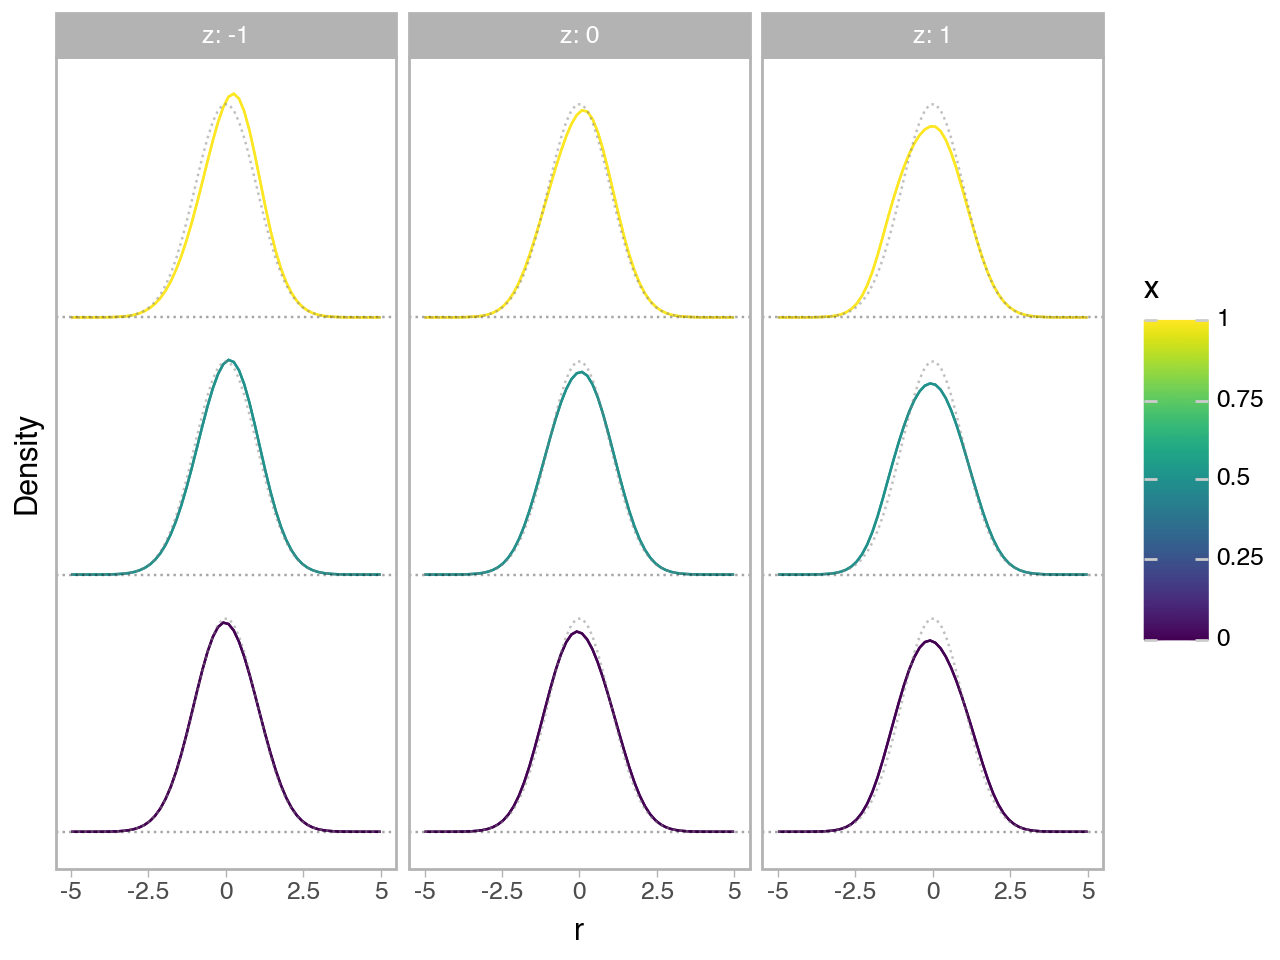

In [4]:
tensor2_data = pd.DataFrame(
    {
        "x": np.linspace(0.0, 1.0, 20),
        "z": np.linspace(-1.0, 1.0, 20),
    }
)
scalar2_builder = gam.TermBuilder.from_df(tensor2_data)
mv2_builder = gam.MVTermBuilder.from_term_builder(scalar2_builder, dimension_scale)
scalar_x = scalar2_builder.f(
    "x", basis_fn=linear_basis, penalty=jnp.eye(2), scale=1.0, use_callback=False
)
scalar_z = scalar2_builder.f(
    "z", basis_fn=linear_basis, penalty=jnp.eye(2), scale=1.0, use_callback=False
)
tensor2 = mv2_builder.tx(scalar_x, scalar_z, dimension_scale=1.0)
main_x = mv2_builder.f(
    "x",
    basis_fn=linear_basis,
    penalty=jnp.eye(2),
    scale=1.0,
    dimension_scale=1.0,
    use_callback=False,
)
tensor2_intercept = mv2_builder.intercept(scale=1.0)
tensor2_model = lsl.Model([tensor2, main_x, tensor2_intercept])
tensor2_samples = {
    **simulated_samples(tensor2, keys[2], scale=0.06),
    **simulated_samples(main_x, keys[3], scale=0.08),
    **simulated_samples(tensor2_intercept, keys[4], scale=0.05),
}

ptm.plot_2d_smooth_dist(
    dist,
    tensor2,
    tensor2_samples,
    rgrid=60,
    ngrid=3,
    facet_by="z",
    marginals=(main_x,),
    intercept=tensor2_intercept,
)

## Three-dimensional tensor interaction

For a `(longitude, latitude, z)` interaction, `plot_3d_smooth_dist_stacked` places spatial density glyphs at paired longitude/latitude anchors, while `plot_3d_smooth_dist` creates a longitude-by-latitude facet grid. Within either design, larger `z` values use higher ridge offsets and the high end of the color scale.

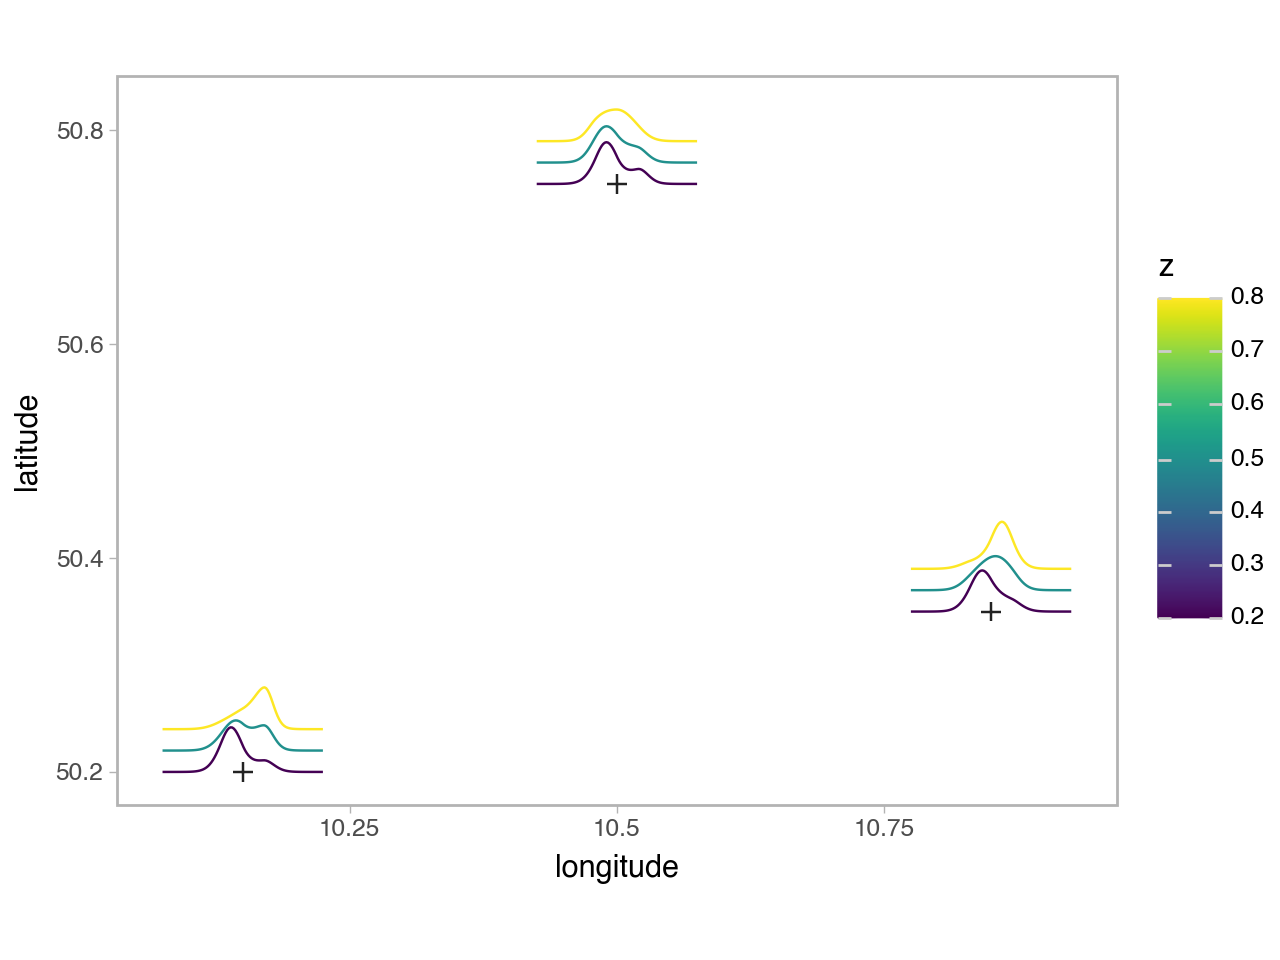

In [5]:
tensor3_data = pd.DataFrame(
    {
        "longitude": np.linspace(10.0, 11.0, 20),
        "latitude": np.linspace(50.0, 51.0, 20),
        "z": np.linspace(0.0, 1.0, 20),
    }
)
scalar3_builder = gam.TermBuilder.from_df(tensor3_data)
mv3_builder = gam.MVTermBuilder.from_term_builder(scalar3_builder, dimension_scale)


def scalar3(name, center, scale):
    def basis(x):
        return linear_basis((x - center) / scale)

    return scalar3_builder.f(
        name,
        basis_fn=basis,
        penalty=jnp.eye(2),
        scale=1.0,
        use_callback=False,
    )


tensor3 = mv3_builder.tx(
    scalar3("longitude", 10.5, 0.5),
    scalar3("latitude", 50.5, 0.5),
    scalar3("z", 0.5, 0.5),
    dimension_scale=1.0,
)
tensor3_model = lsl.Model([tensor3])
tensor3_center = 0.35 * jax.random.normal(keys[8], tensor3.coef.value.shape)
tensor3_samples = simulated_samples(tensor3, keys[5], scale=0.03, center=tensor3_center)
anchor_points = {
    "longitude": np.array([10.15, 10.50, 10.85]),
    "latitude": np.array([50.20, 50.75, 50.35]),
}

ptm.plot_3d_smooth_dist_stacked(
    dist,
    tensor3,
    tensor3_samples,
    x="longitude",
    y="latitude",
    ridge_by="z",
    ridge_spacing=0.02,
    points=anchor_points,
    ridge_values=[0.2, 0.5, 0.8],
    rgrid=jnp.linspace(-5.0, 5.0, 100),
    glyph_width=0.15,
    point_size=3.5,
    point_shape="+",
    point_color="#222222",
    # hdi_prob=0.8,
)

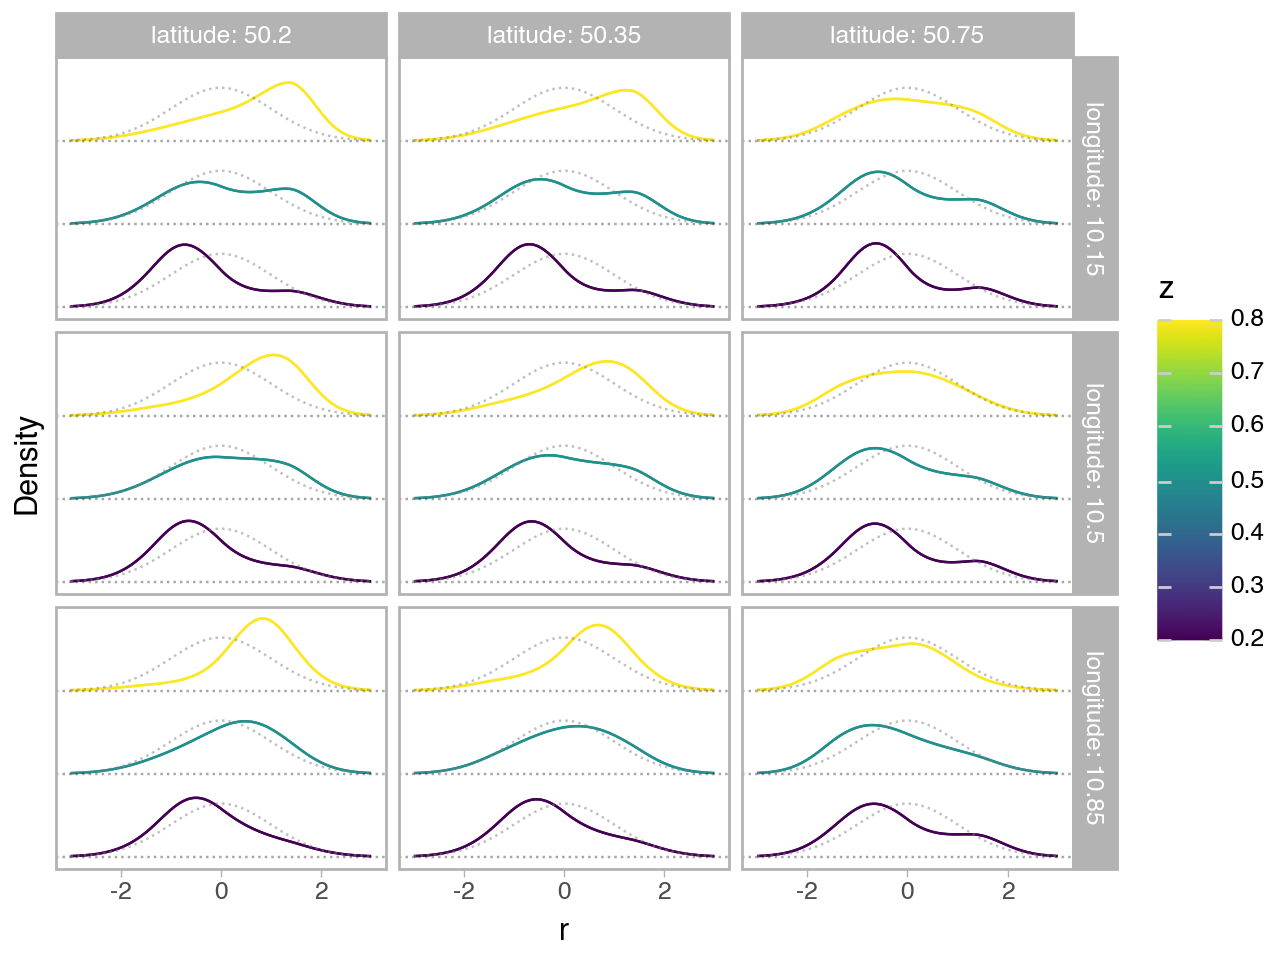

In [6]:
ptm.plot_3d_smooth_dist(
    dist,
    tensor3,
    tensor3_samples,
    x="longitude",
    y="latitude",
    ridge_by="z",
    newdata={**anchor_points, "z": [0.2, 0.5, 0.8]},
    newdata_meshgrid=True,
    rgrid=jnp.linspace(-3.0, 3.0, 100),
)

## Cluster effects

All mapped categories are included, including the unobserved level `d`. Observed status is encoded by line type and categories by color.

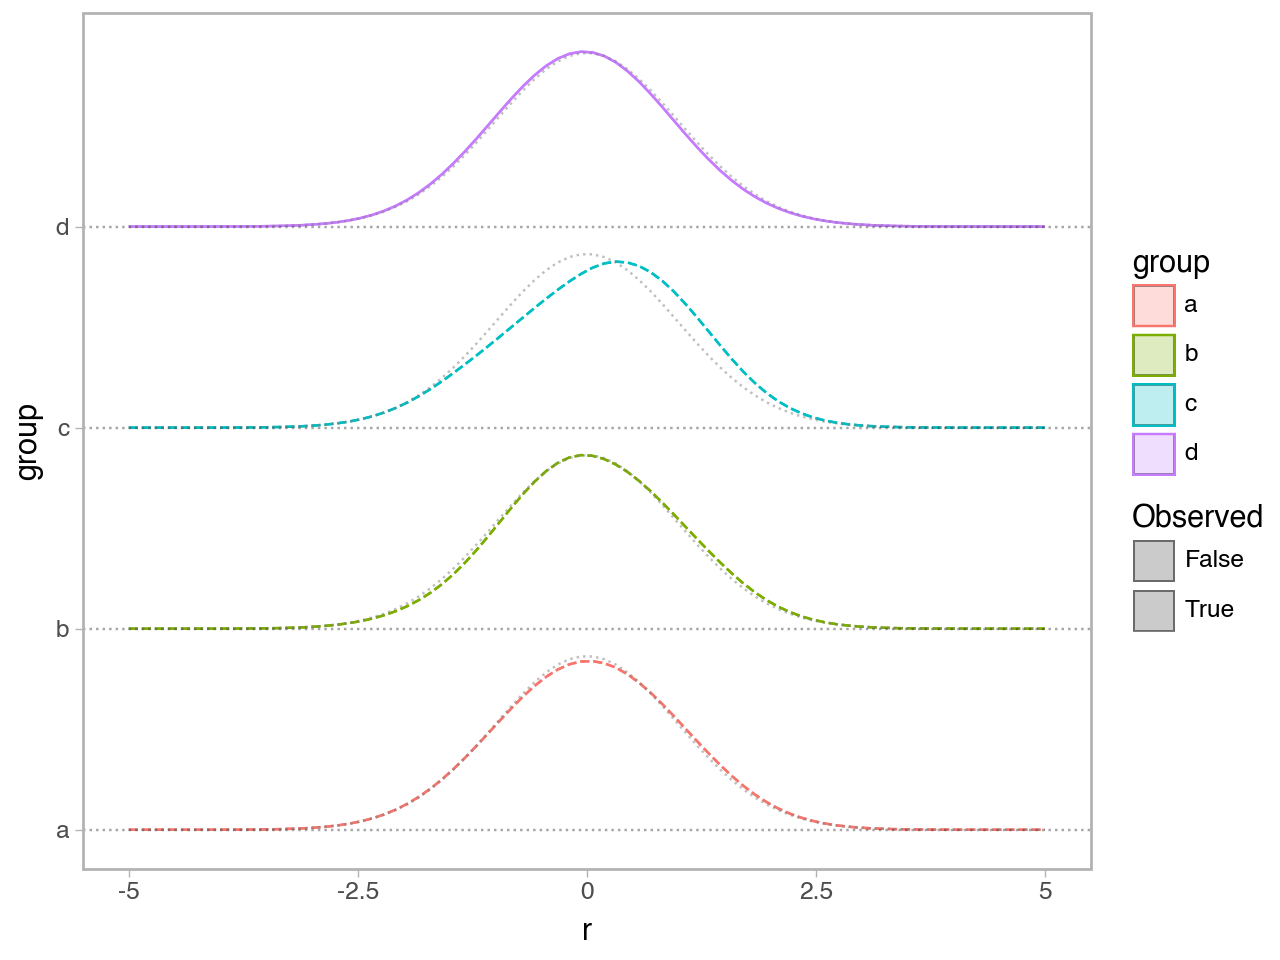

In [7]:
groups = pd.Categorical(["a", "b", "a", "c", "b"], categories=["a", "b", "c", "d"])
cluster_builder = gam.MVTermBuilder.from_df(
    pd.DataFrame({"group": groups}), dimension_scale
)
cluster = cluster_builder.ri("group", scale=1.0, dimension_scale=1.0)
cluster_model = lsl.Model([cluster])
cluster_samples = simulated_samples(cluster, keys[6], scale=0.10)

ptm.plot_cluster_dist(
    dist,
    cluster,
    cluster_samples,
    rgrid=80,
    show_unobserved=True,
    # show_n_samples=4,
)

## Region density glyphs

This example uses the actual Columbus polygon dataframe included in the liesel_gam source checkout. The dataframe is converted to the native polygon mapping once, passed into a multivariate MRF term, and then discovered automatically by `plot_regions_dist`. Polygon centroids supply glyph locations; selected locations can still be overridden with `locations=`.

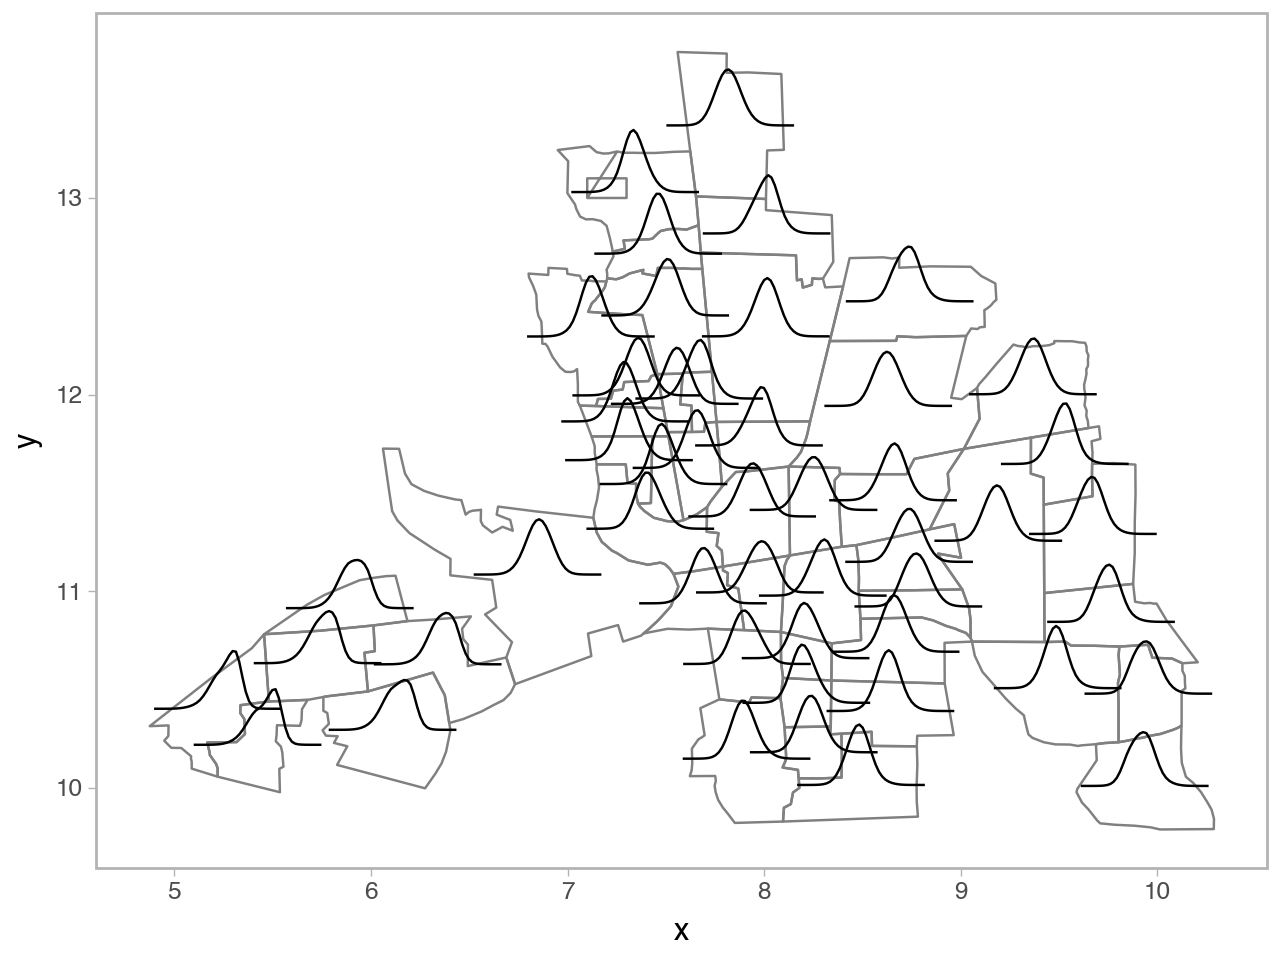

In [8]:
gam_repo = Path(gam.__file__).resolve().parents[2]
columb_dir = gam_repo / "tests" / "mgcv_data"
columb = pd.read_csv(columb_dir / "columb.csv", index_col=0, dtype={"district": str})
districts = [str(i) for i in range(columb["district"].nunique())]
columb["district"] = pd.Categorical(columb["district"], categories=districts)
polys_df = pd.read_csv(columb_dir / "columb_polys.csv", dtype={"label": str})
columb_polys = {
    str(label): group.sort_values("vertex")[["x", "y"]].to_numpy() - 1.0
    for label, group in polys_df.groupby("label", sort=False)
}

region_builder = gam.MVTermBuilder.from_df(columb, dimension_scale)
region = region_builder.mrf(
    "district",
    polys=columb_polys,
    scale=1.0,
    dimension_scale=1.0,
)
region_model = lsl.Model([region])
region_center = jnp.linspace(-0.35, 0.35, region.coef.value.size).reshape(
    region.coef.value.shape
)
region_samples = simulated_samples(region, keys[7], scale=0.04, center=region_center)

ptm.plot_regions_dist(
    dist,
    region,
    region_samples,
    rgrid=40,
    show_density_fill=False,
    hdi_prob=0.8,
)